In [15]:
import numpy as np
import pandas as pd

df = pd.read_csv("three_noisy_signals.csv")

# time axis
t = df["time"].values

# rebuild clean signals from CSV
signal2 = df["signal2_clean"].values
signal3 = df["signal3_clean"].values
signal4 = df["signal4_clean"].values

In [16]:
def corrupt_signal(signal,
                   noise_level=0.25,
                   n_spikes=8,
                   missing_fraction=0.15,
                   delay_steps=3,
                   drift_strength=0.3):

    corrupted = signal.copy()
    N = len(signal)

    # sensor delay
    corrupted = np.roll(corrupted, delay_steps)

    # Gaussian noise
    corrupted += noise_level * np.random.randn(N)

    # time-varying noise
    varying_noise = (0.2 + 0.5 * np.sin(0.2 * t)) * np.random.randn(N)
    corrupted += 0.15 * varying_noise

    # baseline drift
    drift = drift_strength * np.sin(0.15 * t)
    corrupted += drift

    # spikes / dips
    for _ in range(n_spikes):
        center = np.random.randint(0, N)
        amp = np.random.uniform(0.8, 2.0)

        if np.random.rand() < 0.5:
            amp *= -1

        width = np.random.randint(2, 8)

        left = max(0, center - width)
        right = min(N, center + width)

        pulse = np.hanning(right - left)
        corrupted[left:right] += amp * pulse

    # missing chunks
    for _ in range(3):
        start = np.random.randint(0, N - 25)
        length = np.random.randint(8, 25)
        corrupted[start:start+length] = np.nan

    # nonlinear distortion
    corrupted += 0.08 * corrupted**2

    return corrupted

In [17]:
n_samples = 200

X_all = []

for i in range(n_samples):
    signal2_noisy = corrupt_signal(signal2, noise_level=0.25, delay_steps=2)
    signal3_noisy = corrupt_signal(signal3, noise_level=0.20, delay_steps=5)
    signal4_noisy = corrupt_signal(signal4, noise_level=0.30, delay_steps=8)

    X_sample = np.stack(
        [signal2_noisy, signal3_noisy, signal4_noisy],
        axis=1
    )

    X_all.append(X_sample)

X_all = np.array(X_all)

print("X_all shape:", X_all.shape)
print("Missing values:", np.isnan(X_all).sum())

X_all shape: (200, 200, 3)
Missing values: 26936


In [18]:
X_all.shape: (200, 200, 3)

In [19]:
X = df[["signal2_noisy", "signal3_noisy", "signal4_noisy"]].values
X = X[np.newaxis, :, :]

In [20]:
mask = (~np.isnan(X_all)).astype(float)

col_means = np.nanmean(X_all, axis=(0, 1), keepdims=True)
X_filled = np.where(np.isnan(X_all), col_means, X_all)

X_mean = X_filled.mean()
X_std = X_filled.std() + 1e-8

X_norm = (X_filled - X_mean) / X_std

print("X_norm:", X_norm.shape)
print("NaNs:", np.isnan(X_norm).sum())

X_norm: (200, 200, 3)
NaNs: 0


In [21]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam

n_steps = X_norm.shape[1]
n_features = X_norm.shape[2]
latent_dim = 128

inputs = Input(shape=(n_steps, n_features))

# Encoder
# Encoder
encoded = LSTM(128, return_sequences=True)(inputs)
encoded = LSTM(64, return_sequences=False)(encoded)

# Repeat latent vector for each time step
repeated = RepeatVector(n_steps)(encoded)

# Decoder
decoded = LSTM(256, return_sequences=True)(repeated)

# Reconstruct original 3 signals
outputs = TimeDistributed(Dense(n_features))(decoded)

autoencoder = Model(inputs, outputs)

autoencoder.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="mse"
)

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 200, 128)       │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 200, 256)       │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 200, 3)         │           771 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 446,467 (1.70 MB)

 Trainable params: 446,467 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = autoencoder.fit(
    X_norm,
    X_norm,
    epochs=500,
    batch_size=16,
    verbose=1
)

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 560ms/step - loss: 0.9557
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 566ms/step - loss: 0.9084
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 553ms/step - loss: 0.9050
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 547ms/step - loss: 0.9030
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 552ms/step - loss: 0.9013
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 553ms/step - loss: 0.9000
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 557ms/step - loss: 0.8986
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 551ms/step - loss: 0.8973
Epoch 9/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 528ms/step - loss: 0.8959
Epoch 10/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 532ms/step - loss: 0.8943
Epoch 11/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 522ms/step - loss: 0.8924
Epoch 12/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 527ms/step - loss: 0.8901
Epoch 13/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 523ms/step - loss: 0.8854
Epoch 14/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 527ms/step - loss: 0.8764
Epoch 15/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s

In [23]:
X_pred_norm = autoencoder.predict(X_norm)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 372ms/step


In [24]:
X_pred = X_pred_norm * X_std + X_mean
X_true = X_norm * X_std + X_mean

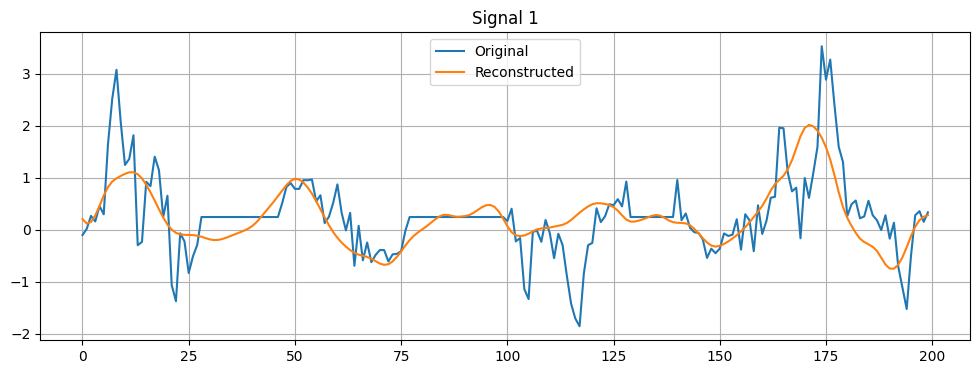

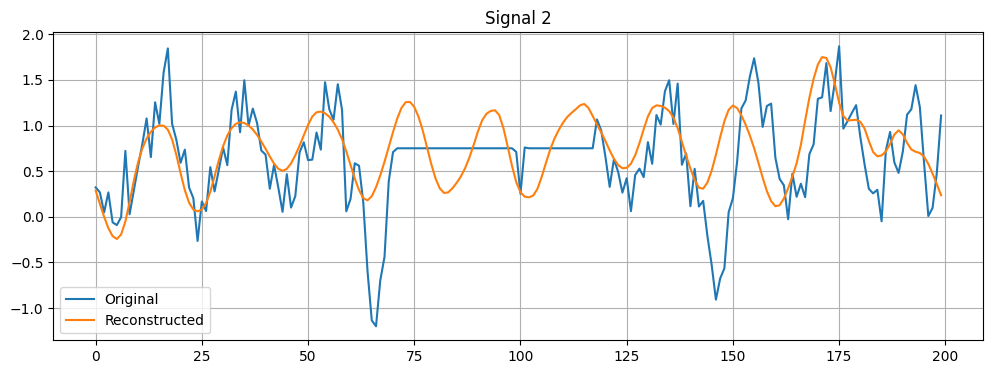

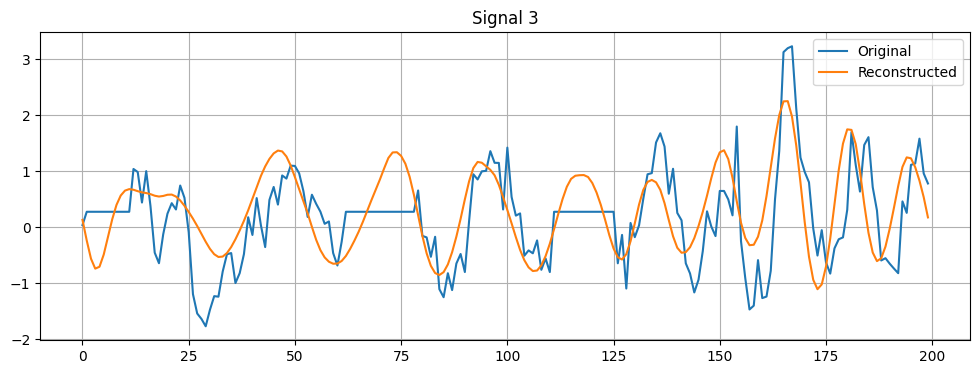

In [25]:
import matplotlib.pyplot as plt

t = np.arange(X_true.shape[1])

for i in range(3):

    plt.figure(figsize=(12,4))

    plt.plot(t, X_true[0,:,i], label="Original")
    plt.plot(t, X_pred[0,:,i], label="Reconstructed")

    plt.title(f"Signal {i+1}")
    plt.legend()
    plt.grid(True)
    plt.show()

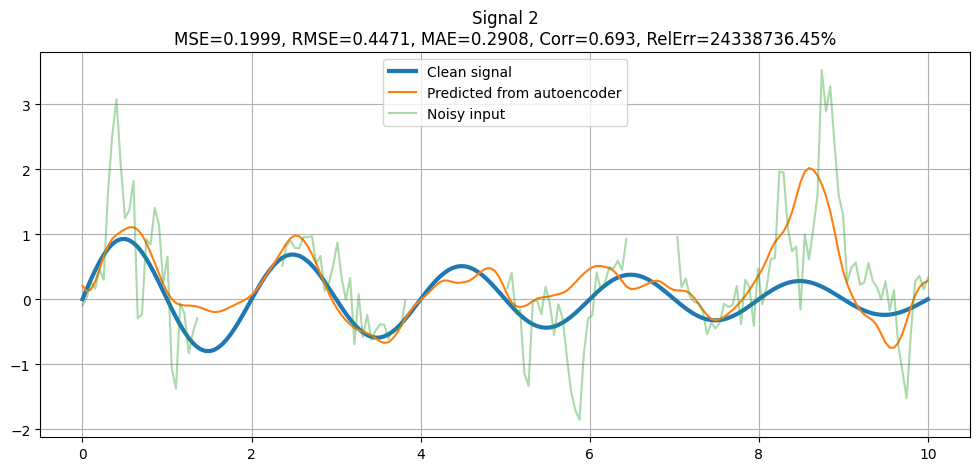


Signal 2
MSE  = 0.199911
RMSE = 0.447114
MAE  = 0.290777
Correlation = 0.6926
Relative Error = 24338736.45%


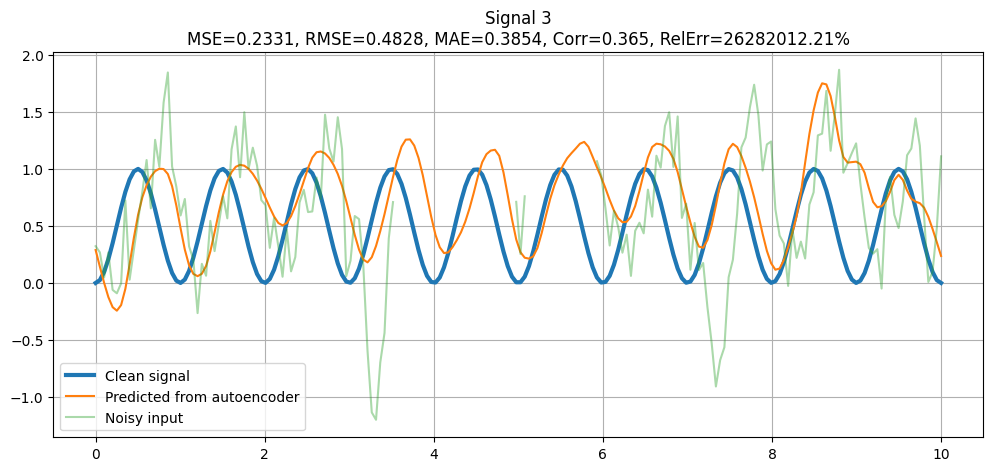


Signal 3
MSE  = 0.233122
RMSE = 0.482827
MAE  = 0.385356
Correlation = 0.3646
Relative Error = 26282012.21%


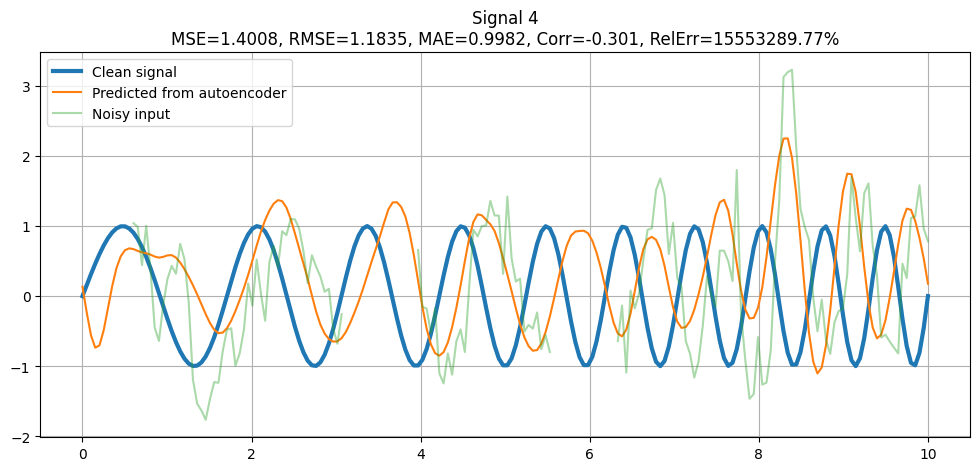


Signal 4
MSE  = 1.400763
RMSE = 1.183538
MAE  = 0.998195
Correlation = -0.3008
Relative Error = 15553289.77%


In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

t_plot = df["time"].values

clean_signals = [signal2, signal3, signal4]

for i in range(3):

    clean = clean_signals[i]
    pred = X_pred[0,:,i]
    noisy = X_all[0,:,i]

    # remove NaNs from noisy if present
    valid = ~np.isnan(pred) & ~np.isnan(clean)

    clean_valid = clean[valid]
    pred_valid = pred[valid]

    # metrics
    mse = mean_squared_error(clean_valid, pred_valid)
    mae = mean_absolute_error(clean_valid, pred_valid)
    rmse = np.sqrt(mse)
    corr = np.corrcoef(clean_valid, pred_valid)[0,1]

    # relative error (%)
    relative_error = 100 * np.mean(
        np.abs(clean_valid - pred_valid) / (np.abs(clean_valid) + 1e-8)
    )

    plt.figure(figsize=(12,5))

    plt.plot(t_plot, clean, label="Clean signal", linewidth=3)
    plt.plot(t_plot, pred, label="Predicted from autoencoder")
    plt.plot(t_plot, noisy, alpha=0.4, label="Noisy input")

    plt.title(
        f"Signal {i+2}\n"
        f"MSE={mse:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}, "
        f"Corr={corr:.3f}, RelErr={relative_error:.2f}%"
    )

    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"\nSignal {i+2}")
    print(f"MSE  = {mse:.6f}")
    print(f"RMSE = {rmse:.6f}")
    print(f"MAE  = {mae:.6f}")
    print(f"Correlation = {corr:.4f}")
    print(f"Relative Error = {relative_error:.2f}%")